===== DATASET INFO =====
   Temperature (°C)  Pressure (kPa)  Temperature x Pressure  \
0        209.762701        8.050855             1688.769167   
1        243.037873       15.812068             3842.931469   
2        220.552675        7.843130             1729.823314   
3        208.976637       23.786089             4970.736918   
4        184.730960       15.797812             2918.345014   

   Material Fusion Metric  Material Transformation Metric  Quality Rating  
0            44522.217074                    9.229576e+06       99.999971  
1            63020.764997                    1.435537e+07       99.985703  
2            49125.950249                    1.072839e+07       99.999758  
3            57128.881547                    9.125702e+06       99.999975  
4            38068.201283                    6.303792e+06      100.000000  

Shape: (3957, 6)

Missing Values:
Temperature (°C)                  0
Pressure (kPa)                    0
Temperature x Pressure           

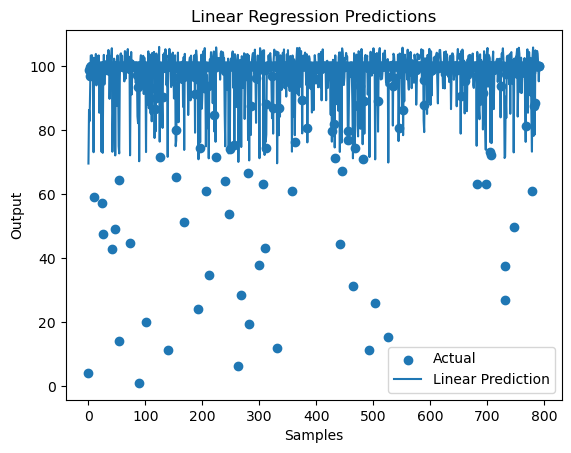

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('manufacturing.csv')

print('===== DATASET INFO =====')
print(df.head())
print('\nShape:', df.shape)
print('\nMissing Values:')
print(df.isnull().sum())

# Encode categorical columns if any
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Features and target (last column assumed target)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- Linear Regression ----------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

print('\n===== LINEAR REGRESSION =====')
print('MAE  :', round(mean_absolute_error(y_test, y_pred_linear),4))
print('MSE  :', round(mean_squared_error(y_test, y_pred_linear),4))
print('RMSE :', round(np.sqrt(mean_squared_error(y_test, y_pred_linear)),4))
print('R2 Score:', round(r2_score(y_test, y_pred_linear),4))

# ---------------- Polynomial Regression ----------------
best_degree = None
best_score = -999

for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    y_pred_poly = poly_model.predict(X_test_poly)
    r2 = r2_score(y_test, y_pred_poly)

    print(f'\n===== POLYNOMIAL REGRESSION Degree {degree} =====')
    print('MAE  :', round(mean_absolute_error(y_test, y_pred_poly),4))
    print('MSE  :', round(mean_squared_error(y_test, y_pred_poly),4))
    print('RMSE :', round(np.sqrt(mean_squared_error(y_test, y_pred_poly)),4))
    print('R2 Score:', round(r2,4))

    if r2 > best_score:
        best_score = r2
        best_degree = degree

print(f'\nBest Polynomial Degree: {best_degree} with R2 Score: {round(best_score,4)}')

# ---------------- Visualization ----------------
plt.scatter(range(len(y_test)), y_test, label='Actual')
plt.plot(range(len(y_pred_linear)), y_pred_linear, label='Linear Prediction')
plt.title('Linear Regression Predictions')
plt.xlabel('Samples')
plt.ylabel('Output')
plt.legend()
plt.show()
